In [ ]:
# Instalação das dependências necessárias para a execução do notebook
%pip install numpy matplotlib torch scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Configuração de sementes fixas para garantir a reprodutibilidade dos experimentos
np.random.seed(42)
torch.manual_seed(42)

Note: you may need to restart the kernel to use updated packages.


## 1. Contextualização Histórica e Motivação

Esta seção apresenta o contexto histórico do desenvolvimento do perceptron e do *Multi Layer Perceptron* (MLP) para fundamentar a evolução e os gargalos do aprendizado de máquina. 

O aprendizado de máquina moderno tem suas raízes em tentativas de replicar o funcionamento do cérebro humano e de suas sinapses nervosas. O primeiro passo formal nessa direção ocorre em 1943, quando Warren McCulloch e Walter Pitts propõem o modelo matemático do neurônio artificial. Em 1957, Frank Rosenblatt leva esse conceito para o *hardware* com a implementação do Perceptron no computador Mark I. O perceptron atua como um classificador linear simples, recebendo variáveis de entrada, aplicando pesos sinápticos e utilizando uma função degrau para tomar uma decisão binária.

Apesar do entusiasmo inicial, a solução apresenta limitações severas. Em 1969, os pesquisadores Marvin Minsky e Seymour Papert provam matematicamente que um perceptron de camada única é incapaz de resolver problemas que não são linearmente separáveis, utilizando o problema lógico **XOR (Ou Exclusivo)** como exemplo clássico. Isso demonstra que o classificador não consegue lidar com não-linearidades, o que estagnou a pesquisa na área por anos.

A solução para a insuficiência do perceptron único exige a adição de múltiplas camadas (*Multi Layer Perceptron*) e o uso de funções de ativação não lineares (como *Sigmoid* ou *Tanh*). Contudo, não existia um método eficiente para atualizar os pesos em redes com camadas ocultas. O MLP torna-se viável em larga escala apenas em 1986, quando Geoffrey Hinton e seus colaboradores introduzem o algoritmo de *Backpropagation*.

No estado atual da área (2024-2025), os perceptrons multicamadas continuam sendo a espinha dorsal da Inteligência Artificial. Camadas lineares densas (*Fully Connected*) baseadas no algoritmo original compõem partes vitais de arquiteturas massivas contemporâneas, atuando, por exemplo, nas redes *Feed-Forward* presentes dentro de cada bloco de modelos *Transformers* e LLMs.

## 2. Intuição e Visualização

Esta seção constrói a intuição geométrica da separabilidade linear e seus limites para ilustrar visualmente a necessidade de redes profundas.

O perceptron clássico tenta traçar uma reta (ou *hiperplano*, em dimensões superiores) para dividir duas classes de dados num plano cartesiano bidimensional. Se os dados pertencem a uma classe 0 e a uma classe 1, a reta define uma fronteira de decisão. Portas lógicas como **AND** (E) e **OR** (OU) possuem distribuições onde é perfeitamente possível desenhar uma única reta que isole os dados verdadeiros dos falsos. No entanto, o problema **XOR** (Ou Exclusivo) contém pontos cruzados: as classes estão dispostas de forma que nenhuma reta singular consegue isolá-las sem cometer erros de classificação.

Observe que, no código abaixo, a visualização materializa o conceito de separabilidade.


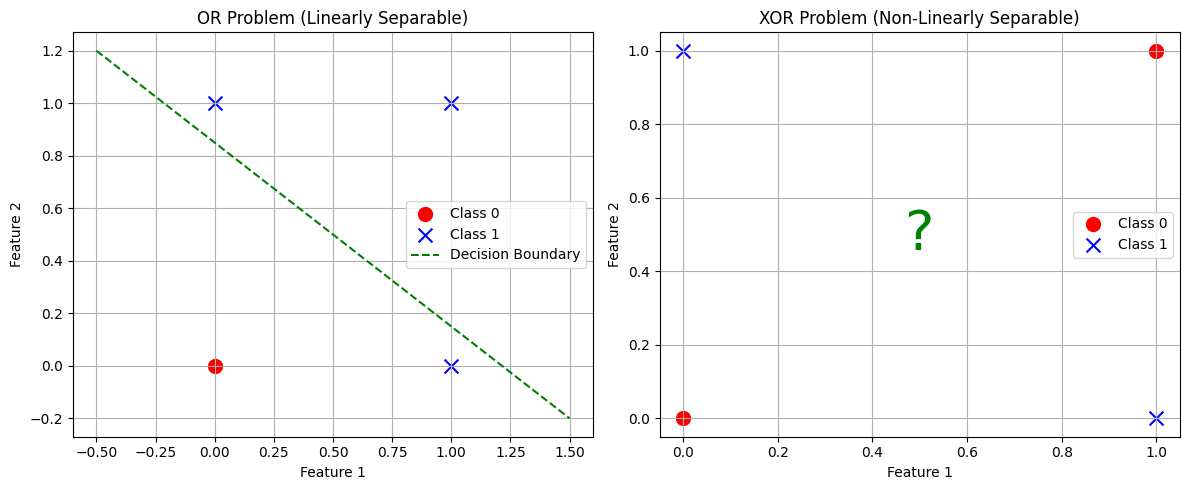

In [ ]:
def plot_decision_boundary_intuition():
    """Gera visualização geométrica de problemas linearmente separáveis vs não separáveis."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Dados da porta OR (Linearmente Separável)
    X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_or = np.array([0, 1, 1, 1])
    
    # Dados da porta XOR (Não Linearmente Separável)
    X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([0, 1, 1, 0])
    
    # Plot OR
    axes[0].scatter(X_or[y_or == 0][:, 0], X_or[y_or == 0][:, 1], color='red', marker='o', s=100, label='Class 0')
    axes[0].scatter(X_or[y_or == 1][:, 0], X_or[y_or == 1][:, 1], color='blue', marker='x', s=100, label='Class 1')
    axes[0].plot([-0.5, 1.5], [1.2, -0.2], color='green', linestyle='--', label='Decision Boundary')
    axes[0].set_title('OR Problem (Linearly Separable)')
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot XOR
    axes[1].scatter(X_xor[y_xor == 0][:, 0], X_xor[y_xor == 0][:, 1], color='red', marker='o', s=100, label='Class 0')
    axes[1].scatter(X_xor[y_xor == 1][:, 0], X_xor[y_xor == 1][:, 1], color='blue', marker='x', s=100, label='Class 1')
    axes[1].set_title('XOR Problem (Non-Linearly Separable)')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].text(0.5, 0.5, '?', fontsize=40, color='green', ha='center', va='center')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_decision_boundary_intuition()

# 3. Teoria Formal

Esta seção define matematicamente o modelo do perceptron e suas atualizações para estabelecer o rigor analítico necessário para a formulação de algoritmos de otimização.

O neurônio perceptron executa duas operações fundamentais: uma soma ponderada das entradas e uma função de ativação. Define-se o vetor de entrada $X$ de tamanho $N$ e o vetor de pesos sinápticos $W$ de tamanho $N$, somados a um termo de viés (bias) $b$. A soma linear é expressa por:

$$ z = \sum_{i=1}^{N} x_i w_i + b $$

A saída predita $\hat{y}$ é definida por uma função de ativação degrau, limitando o problema a uma classificação binária:

$$ \hat{y} = f(z) = \begin{cases} 1 & \text{se } z \ge 0 \\ 0 & \text{caso contrário} \end{cases} $$

Para o treinamento, a atualização dos pesos exige uma métrica de erro, definida por $e = y - \hat{y}$. O algoritmo minimiza esse erro utilizando a regra de atualização do perceptron, parametrizada pela taxa de aprendizado (*learning rate*, $\eta$), que dita a agressividade da mudança:

$$ w_i^{(t+1)} = w_i^{(t)} + \eta \cdot (y - \hat{y}) \cdot x_i $$

**Operações Matriciais e Paralelismo:**
Para processar *batches* (lotes) de dados, a notação escalar transforma-se em multiplicação matricial. Dada uma matriz de entrada $\mathbf{X}$ de formato $(M \times N)$ e uma matriz de pesos $\mathbf{W}$ de formato $(N \times 1)$, a predição em bloco torna-se:

$$ \mathbf{\hat{Y}} = \mathbf{X}\mathbf{W} + \mathbf{B} $$

O uso desta representação matricial embasa a viabilidade do aprendizado de máquina moderno, já que operações matriciais são otimizadas e executadas paralelamente em GPUs. 

*Limitações e hipóteses:* O Teorema da Convergência do Perceptron garante que o algoritmo encontrará uma solução de erro zero se, e somente se, o conjunto de dados for linearmente separável. Problemas de representação mais profunda demandam o MLP.
A arquitetura do MLP introduz camadas ocultas densas (*Fully Connected*). A passagem de informações por camadas segue a formulação:
$$ H^{(l)} = f(\mathbf{X} \mathbf{W}^{(l)} + \mathbf{B}^{(l)}) $$
Onde a função $f$ deixa de ser um degrau linear e passa a ser não-linear, viabilizando distorções nos hiperplanos.

*Nota de divergência:* O vídeo aula aponta a estratégia de concatenar o viés $b$ como um peso extra em $W$ e uma constante $1$ em cada vetor $X$, transformando a equação $\mathbf{X}\mathbf{W} + b$ em uma multiplicação estrita $\mathbf{X'}\mathbf{W'}$. Na prática moderna com tensores, mantém-se o viés isolado usando a funcionalidade de *broadcasting*.

# 4. Algoritmos

Esta seção exibe o pseudocódigo do treinamento do perceptron para mapear as fórmulas algébricas em uma estrutura de execução lógica.

O algoritmo executa de forma iterativa por um número estipulado de passagens chamadas *epochs* (épocas).

```text
Algoritmo: Treinamento do Perceptron
Entrada: X (matriz de características), y (vetor de rótulos verdadeiros)
Parâmetros: eta (taxa de aprendizado), epochs (número de iterações)

1. Inicialize pesos W com zeros (tamanho igual ao número de características)
2. Inicialize bias b com zero
3. Para epoca de 1 até epochs faça:
4.     Para cada amostra x_i e rótulo y_i nos dados:
5.         // Forward pass (Cálculo da predição linear)
6.         z = produto_escalar(x_i, W) + b
7.         Se z >= 0 então y_pred = 1
8.         Senão y_pred = 0
9.         
10.        // Cálculo do erro
11.        erro = y_i - y_pred
12.        
13.        // Atualização dos parâmetros
14.        W = W + eta * erro * x_i
15.        b = b + eta * erro
16. Retorna W, b
```

O primeiro passo do algoritmo configura o ponto de partida do hiperplano. Durante cada *epoch*, a avaliação individual da amostra dita o passo de ajuste dos vetores $W$ e $b$. Se a predição é correta (`erro = 0`), os pesos não mudam, indicando estabilidade local do gradiente.

# 5. Implementação from scratch

Esta seção implementa a classe fundamental do perceptron em Python usando estritamente as operações matriciais do pacote NumPy para desmistificar o comportamento interno do modelo de caixa-preta.

In [ ]:
class PerceptronFromScratch:
    """
    Implementação do Perceptron Clássico para classificação binária.
    """
    def __init__(self, learning_rate: float = 0.01, epochs: int = 1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """Ajusta os parâmetros (pesos e bias) com base nos dados de treino."""
        n_samples, n_features = X.shape
        # Inicializa parâmetros de rede com zeros
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        # Laço iterativo de treinamento
        for _ in range(self.epochs):
            for idx, x_i in enumerate(X):
                # Cálculo linear: w * x + b
                linear_output = np.dot(x_i, self.weights) + self.bias
                
                # Função de ativação (Degrau)
                y_pred = 1 if linear_output >= 0 else 0
                
                # Atualização matemática
                update = self.learning_rate * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Recebe matriz X e retorna as classes preditas."""
        linear_output = np.dot(X, self.weights) + self.bias
        # Aplica threshold: onde é maior igual a 0 vira 1, senão 0.
        y_pred = np.where(linear_output >= 0, 1, 0)
        return y_pred

# --- BATERIA DE TESTES (ASSERT) ---
# Validando o modelo clássico frente a uma operação linear (porta OR)
X_or_test = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or_test = np.array([0, 1, 1, 1])

model = PerceptronFromScratch(learning_rate=0.1, epochs=10)
model.fit(X_or_test, y_or_test)
predictions = model.predict(X_or_test)

# Verifica se o modelo convergiu com 100% de precisão num dataset linearmente separável
assert np.array_equal(predictions, y_or_test), "O modelo não conseguiu aprender uma porta OR simples."
print("Implementação From Scratch testada com sucesso na porta OR. Pesos aprendidos:", model.weights)

Implementação From Scratch testada com sucesso na porta OR. Pesos aprendidos: [0.1 0.1]


# 6. Implementação em PyTorch

Esta seção reproduz o conceito de Multi Layer Perceptron utilizando tensores do framework PyTorch para contornar a limitação imposta por problemas não lineares como o XOR.

Como provado historicamente e abordado na aula, um perceptron singular é incapaz de mapear saídas para distribuições não linearmente separáveis (XOR). Resolve-se esse impasse instanciando uma pequena rede neural `nn.Module` de arquitetura profunda, possuindo uma camada conectada oculta (`hidden`) e uma função não linear de ativação (`Sigmoid`), emulando as condições apontadas pelo teorema de backpropagation.

In [ ]:
class MLP_PyTorch(nn.Module):
    """
    Implementação de uma rede neural Multi Layer Perceptron para o problema XOR.
    A arquitetura contempla 2 entradas, 4 neurônios na camada oculta, e 1 saída.
    """
    def __init__(self):
        super(MLP_PyTorch, self).__init__()
        # Mapeamento do espaço original para um espaço vetorial de maior dimensão (2 -> 4)
        self.hidden_layer = nn.Linear(2, 4)
        # Transformação não linear requerida para separabilidade complexa
        self.activation = nn.Sigmoid()
        # Agrupamento para a predição binária (4 -> 1)
        self.output_layer = nn.Linear(4, 1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Define o fluxo forward da rede."""
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        # O output do MLP usará uma sigmoide para gerar probabilidade entre 0 e 1
        return torch.sigmoid(x)

def train_and_test_mlp():
    """Treina o MLP no problema XOR e aplica uma bateria de testes."""
    # Dados XOR transformados em tensores de ponto flutuante
    X_xor_torch = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
    y_xor_torch = torch.tensor([[0.0], [1.0], [1.0], [0.0]])
    
    mlp = MLP_PyTorch()
    # A perda Binary Cross Entropy (BCE) é a padrão em PyTorch para classificação probabilística
    criterion = nn.BCELoss()
    # O otimizador SGD substitui a atualização manual dos pesos da formulação from_scratch
    optimizer = optim.SGD(mlp.parameters(), lr=0.5)
    
    epochs = 5000
    for epoch in range(epochs):
        optimizer.zero_grad()            # Zera gradientes iterativos
        outputs = mlp(X_xor_torch)       # Foward pass
        loss = criterion(outputs, y_xor_torch) # Cálculo do custo
        loss.backward()                  # Backward pass (Backpropagation)
        optimizer.step()                 # Atualização dos pesos (Descent)

    # Previsão final
    with torch.no_grad():
        final_preds = mlp(X_xor_torch).numpy()
        binary_preds = np.where(final_preds >= 0.5, 1, 0)
        
    # Verifica se a rede multicamadas conseguiu quebrar a limitação do perceptron
    assert np.array_equal(binary_preds, y_xor_torch.numpy()), "MLP PyTorch não conseguiu resolver o XOR."
    print("Implementação MLP PyTorch testada e convergiu com sucesso no problema XOR.")

train_and_test_mlp()

Implementação MLP PyTorch testada e convergiu com sucesso no problema XOR.


# 7. Experimentos e Análise

Esta seção examina a dinâmica do hiperparâmetro da taxa de aprendizado em experimentos de convergência do Perceptron para diagnosticar problemas de instabilidade.

A taxa de aprendizado (*learning rate*) dita o tamanho do passo que o vetor de pesos realiza em direção ao mínimo do erro. Taxas excessivamente altas geram oscilação ou divergência dos pesos; taxas irrisórias implicam travamento em mínimos locais ou um número colossal de passagens para o aprendizado adequado.

O experimento a seguir utiliza dois valores diferentes e traça o comportamento cumulativo do ajuste para expor instabilidades. Diagnostica-se convergências lentas através da ausência de achatamento no gráfico em menos passagens.

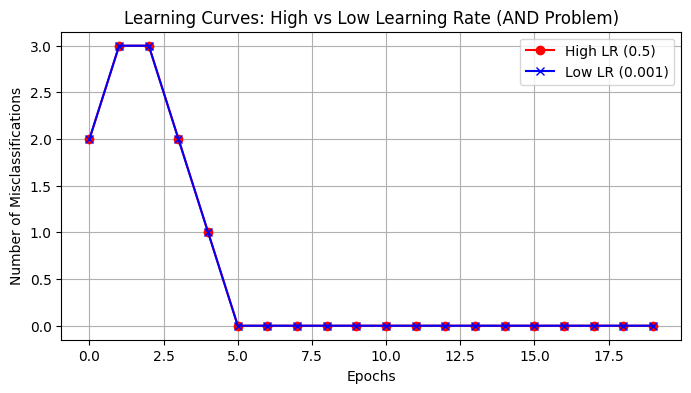

In [ ]:
def experiment_learning_rates():
    """Roda dois experimentos independentes com o classificador para avaliar a taxa de aprendizado."""
    # Dataset linear simples (Problema AND)
    X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_and = np.array([0, 0, 0, 1])
    
    rates = [0.5, 0.001]
    histories = []
    
    for lr in rates:
        model = PerceptronFromScratch(learning_rate=lr, epochs=20)
        # Armazenar histórico de erro para análise (alterando levemente a função fit de dentro para logging)
        n_samples, n_features = X_and.shape
        model.weights = np.zeros(n_features)
        model.bias = 0.0
        
        errors_in_epoch = []
        for _ in range(model.epochs):
            total_error = 0
            for idx, x_i in enumerate(X_and):
                linear_output = np.dot(x_i, model.weights) + model.bias
                y_pred = 1 if linear_output >= 0 else 0
                error = y_and[idx] - y_pred
                if error != 0:
                    total_error += 1
                update = model.learning_rate * error
                model.weights += update * x_i
                model.bias += update
            errors_in_epoch.append(total_error)
        histories.append(errors_in_epoch)
        
    # Plot dos resultados dos experimentos
    plt.figure(figsize=(8, 4))
    plt.plot(histories[0], label=f'High LR ({rates[0]})', color='red', marker='o')
    plt.plot(histories[1], label=f'Low LR ({rates[1]})', color='blue', marker='x')
    plt.title("Learning Curves: High vs Low Learning Rate (AND Problem)")
    plt.xlabel("Epochs")
    plt.ylabel("Number of Misclassifications")
    plt.legend()
    plt.grid(True)
    plt.show()

experiment_learning_rates()

# 8. Conexões com ML Moderno

Esta seção conecta a arquitetura primordial do MLP às estruturas neurais da fronteira atual, respondendo ao questionamento da utilidade e relevância perene do modelo.

O Perceptron e as redes *Multi Layer Perceptron* (MLP) são comumente denominadas redes *Fully Connected* (Totalmente Conectadas) na literatura moderna. A matemática de atualização propagada por retropropagação idealizada por Rumelhart, Hinton e Williams (1986) permanece intacta nas *pipelines* de arquiteturas que parecem distantes da sua natureza inicial. 

Por que o MLP ainda importa em 2025? No coração das arquiteturas mais disruptivas, incluindo *Transformers* e Modelos de Difusão (Latent Diffusion), localizam-se os blocos de FFN (*Feed-Forward Networks*). Em um *Transformer*, após calcular as projeções atencionais (*Self-Attention*), o processamento local dos vetores de cada token realiza-se por camadas lineares densas clássicas conectadas por funções não lineares como ReLU, GeLU ou SwiGLU. As matrizes de peso descritas no problema do perceptron são exatamente as mesmas bases operacionais responsáveis pela capacidade semântica e latente dos modelos que compõem a vanguarda atual da Inteligência Artificial.

# 9. Exercícios

Esta seção lista os exercícios teóricos e os desafios abertos de código com o propósito de avaliar a assimilação dos conteúdos matemáticos e topológicos.

**Exercícios Resolvidos:**

1. **Pergunta:** Explique por qual razão a função degrau utilizada no perceptron nativo inviabiliza o treinamento por meio da técnica de retropropagação (*Backpropagation*).

   *Solução Comentada:* O algoritmo de *backpropagation* ajusta os parâmetros das camadas inferiores utilizando a regra da cadeia e os gradientes da função de erro em relação às ativações. A função degrau do perceptron não é derivável (ou apresenta derivada zero) na sua extensão, impossibilitando que o gradiente da rede propague os erros de saída para as conexões ocultas. Subsitui-se essa abordagem por curvas suaves com gradiente contínuo, como Sigmoid ou Tanh.

2. **Pergunta:** Descreva qual o ganho em termos de computação, ao acoplar o viés $b$ como uma dimensão na matriz de pesos, conforme narrado na aula.

   *Solução Comentada:* Se o viés $b$ permanece isolado da multiplicação matricial, as GPUs precisarão de um ciclo de operação a mais (multiplicação + adição vetorial subsequente). Acrescentando o valor constante $1$ em todo vetor de entrada de dados e fundindo o $b$ aos parâmetros da matriz $W$, realiza-se o processo como uma única e pura multiplicação matricial rápida $\mathbf{X_{modificada}}\mathbf{W_{modificada}}$.

3. **Pergunta:** Demonstre matematicamente, dada uma camada $n$ indo para uma camada vizinha $n$, qual o montante de conexões do MLP.

   *Solução Comentada:* Numa arquitetura multicamadas densa, também descrita como *fully connected*, cada neurônio da camada base conecta-se individualmente a cada neurônio da camada receptora. Trata-se de uma matriz cujas fileiras representam os pontos base e colunas os pontos receptores. Tendo $N$ pontos iniciais conectando em $N$ pontos de destino, o montante totaliza exatamente $N^2$ conexões.

**Desafios Abertos:**

1. **Early Stopping em OOP:** Modifique o pseudocódigo ou a classe do `PerceptronFromScratch` instanciada na Seção 5 para incluir o parâmetro `early_stopping`. *Dica: Se a validação e atualização resultarem em alteração zero no vetor de pesos após uma epoch global (ou seja, `total_error == 0`), rompa o laço usando um condicional e evite rodar iterações ociosas.*

2. **Multiclasse One-vs-Rest:** A implementação atual performa estritamente classificações binárias. Implemente um invólucro em PyTorch que instancie múltiplos perceptrons, em que cada qual preveja "Classe A vs Resto", utilizando uma camada superior de `argmax` para extrair qual perceptron apresentou ativação com maior confiança na dimensão final. *Dica: Consulte as abordagens multiclasse de OVR (One-Vs-Rest) aplicadas na redução de tensores.*